In [1]:
llm = 'azure-o1-mini'
temperature = 0
instructions = '''\
    The user will input an outline for a manuscript on a specific topic. You are a scholarly ghost‑writer with a PhD in that topic area. Your task is to convert a detailed, hierarchically coded outline into polished manuscript prose. Follow the following global constraints for every section you draft.
 
    **Your writing must be consistent with previous section**

    **Voice & register**
    
    - Doctoral‑level, formal scientific style (as in a peer‑reviewed journal).
    - Integrate definitions, mechanisms, empirical findings and theoretical nuance as appropriate.
    - Write at great enough depth that the reader will fully understand the various aspects of the sub section, but avoid being overly redundant with other sections.
    
    **Form**

    - Only paragraphs — no headings, no numbering, no bullet points, no embedded outline codes.
    - You may use multiple paragraphs if needed to cover the content deeply and coherently.
    
    **Use of outline**
    
    - Each outline line is structured as “<alphanumeric code> -> <level‑1 topic> -> <level‑2 topic> -> …”.
    - Treat higher‑level nodes as contextual background, lower‑level nodes as focal content.
    - Avoid repeating detailed explanations already supplied for earlier sections unless essential for clarity; instead, use concise forward/backward references if necessary.
    - Confidence scoring: For each factual statement generated, include a confidence score between 1-10 (1 being the lowest and 10 being the highest) in the form of “(CS= [score])”. This score should reflect the level of scientific consensus or evidence supporting the statement, with 1 indicating speculative or weakly supported claims and 10 indicating well-established facts.),

    **Writing Depth and Style**
    
    - Where deemed necessary to illustrate a point/provide clarity, employ specific/detailed examples that help the reader better understand critical concepts.
    - When responding your sole values should be scientific accuracy, application of rigorous scientific reasoning, and material reasoning/rationality.
    - Identify hidden biases in your answer and correct them.
    '''

Using azure-o1-mini with temperature 0



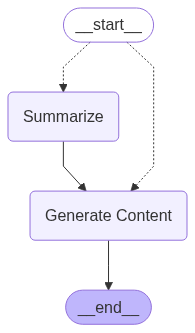

In [4]:
from src.backend.architecture import Architecture
agent = Architecture(model_name=llm, temperature=temperature, instructions=instructions).agent

from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

Using azure-o1-mini with temperature 0 in rag architecture



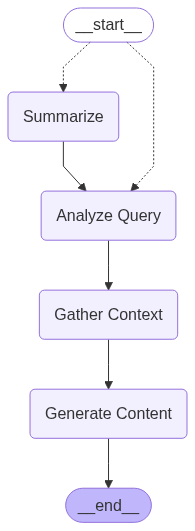

In [2]:
from src.backend.architecture import Architecture
agent = Architecture(model_name=llm, temperature=temperature, instructions=instructions, type='rag', collection_name='ai_word_processor_collection_34').agent

from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [3]:
content_pre = '# Title: Hypertensive Disorders of Pregnancy: A Comprehensive Review of Pathophysiology, Clinical Management, Long-Term Implications, and Future Directions\n\n## I. Introduction'
current_section = '# Title: Hypertensive Disorders of Pregnancy: A Comprehensive Review of Pathophysiology, Clinical Management, Long-Term Implications, and Future Directions\n\n## I. Introduction\n\n<content>'

agent.invoke({'content_pre': content_pre, 'current_section': current_section}, {"configurable": {"thread_id": "abc123"}})

/Users/talukdera2/Desktop/projects/ods/word_processor_ai/.venv/lib/python3.12/site-packages/langchain_core/vectorstores/base.py:1082: UserWarning: Relevance scores must be between 0 and 1, got [(Document(id='6a080fe2-5a07-4035-9ab5-41bc12277ded', metadata={'robots': 'noindex', 'author': 'Michael S. Tanner BMedSc (Hons)', 'title': 'The evolution of the diagnostic criteria of preeclampsia-eclampsia', 'creator': 'Elsevier', 'subject': 'The American Journal of Obstetrics & Gynecology, 226 (2022) 835-843. doi:10.1016/j.ajog.2021.11.1371', 'elsevierwebpdfspecifications': '7.0', 'creationdate': '11th February 2022', 'page': '7', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'doi': '10.1016/j.ajog.2021.11.1371', 'moddate': '2022-02-11T10:10:21+05:30', 'crossmarkmajorversiondate': '2010-04-23', 'crossmarkdomains[2]': 'elsevier.com', 'crossmarkdomainexclusive': 'true', 'start_index': 2356, 'crossmarkdomains[1]': 'sciencedirect.com', 'page_label': 'S842', 'creationdate--text': '11th February 2

KeyError: 'filename'

In [19]:
from src.backend.vectordb import getLoader
from utils import Config
from pathlib import Path

# createVectorDBCollection(collection_name='test',
#                         file_paths=[Config.DIR_DATA / 'uploaded_docs' / '10.docx'])

file_paths=[Config.DIR_DATA / 'uploaded_docs' / '28.pdf']

docs = []

for file_path in file_paths:

    loader = getLoader(file_path=file_path)
    
    for doc in loader:
        doc.metadata = {**{'app_file_id': Path(file_path).stem}, **{k: str(v) for k, v in doc.metadata.items()}}
        docs.append(doc)

In [20]:
from src.backend.vectordb import ChromaDB

db = ChromaDB()
db.create(collection_name='test_graph', delete_if_exists=True)
db.add(docs=docs, is_graph=True)

In [15]:
from src.backend.vectordb import ChromaDB

db = ChromaDB()

db.get(collection_name='test_graph', is_graph=True)
results = db.retriever.invoke('pregnancy and preaclampsia')

In [21]:
results

[Document(id='11c73a72-0951-498b-b843-65cec8ca5f56', metadata={'_depth': 0, '_similarity_score': np.float64(0.5282127593502334), 'subject': 'The American Journal of Obstetrics & Gynecology, 226 (2022) 835-843. doi:10.1016/j.ajog.2021.11.1371', 'page_label': 'S842', 'creationdate--text': '11th February 2022', 'producer': 'Acrobat Distiller 8.1.0 (Windows)', 'doi': '10.1016/j.ajog.2021.11.1371', 'creationdate': '11th February 2022', 'total_pages': 9, 'crossmarkdomains[1]': 'sciencedirect.com', 'source': '/Users/talukdera2/Desktop/projects/ods/word_processor_ai/data/uploaded_docs/28.pdf', 'creator': 'Elsevier', 'title': 'The evolution of the diagnostic criteria of preeclampsia-eclampsia', 'crossmarkdomainexclusive': 'true', 'crossmarkdomains[2]': 'elsevier.com', 'page': 7, 'crossmarkmajorversiondate': '2010-04-23', 'robots': 'noindex', 'author': 'Michael S. Tanner BMedSc (Hons)', 'moddate': '2022-02-11T10:10:21+05:30', 'elsevierwebpdfspecifications': '7.0'}, page_content='Finally, measuri

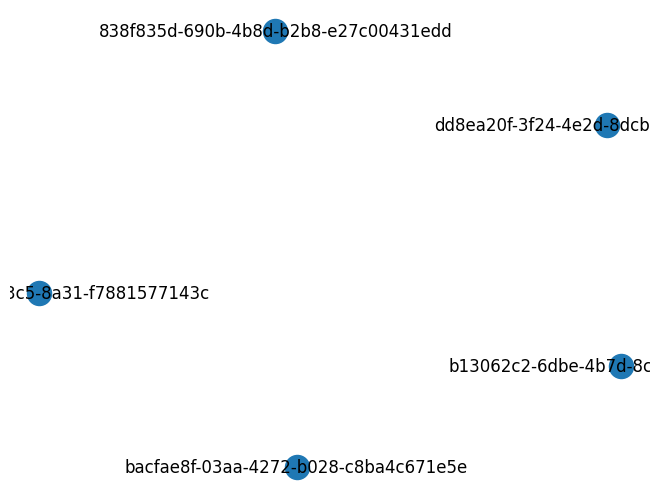

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from langchain_graph_retriever.document_graph import create_graph

document_graph = create_graph(
    documents=results,
    edges = db.retriever.edges,
)

t = nx.Graph(document_graph)
nx.draw(document_graph, with_labels=True)
plt.show()

In [5]:
document_graph.nodes

NodeView(('dd8ea20f-3f24-4e2d-8dcb-e6b8c832a287', 'b13062c2-6dbe-4b7d-8c93-d1cff3da8bcb', 'bacfae8f-03aa-4272-b028-c8ba4c671e5e', '838f835d-690b-4b8d-b2b8-e27c00431edd', 'fcf44e8e-a3b2-43c5-8a31-f7881577143c'))

In [7]:
from pyvis.network import Network

nt = Network('500px', '500px')
nx_graph = nx.Graph()
for k, v in document_graph.nodes.items():
    nx_graph.add_node(k, size=20)
                      
#nt = Network('500px', '500px')
nt.from_nx(nx_graph)
nt.show('nx.html', notebook=False, )

nx.html
